In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew 
from sklearn.model_selection import train_test_split 
from sklearn.pipeline import Pipeline #Pipeline可以将多个数据处理步骤（如特征缩放、特征选择、模型训练等）组合成一个整体，
from sklearn.compose import ColumnTransformer
#  对数据框（DataFrame）的不同列应用不同的预处理步骤（例如，对数值列和分类列进行不同的处理）。
from sklearn.impute import SimpleImputer
# 处理缺失值，提供了几种填充缺失值的策略，例如用均值、中位数、众数或常数填充。
from sklearn.preprocessing import OrdinalEncoder, RobustScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings  # 设置警告过滤器，忽略所有警告信息
warnings.filterwarnings('ignore')

In [4]:
# 读取文件
train_ori = pd.read_csv(r"data\train.csv", low_memory=False)
test_ori = pd.read_csv(r"data\test.csv", low_memory=False)

In [28]:
train = train_ori.copy()
test = test_ori.copy()

In [6]:
train.shape

(177024, 508)

In [7]:
train.head()

,id,p_num,time,bg-5:55,bg-5:50,bg-5:45,bg-5:40,bg-5:35,bg-5:30,bg-5:25,...,activity-0:40,activity-0:35,activity-0:30,activity-0:25,activity-0:20,activity-0:15,activity-0:10,activity-0:05,activity-0:00,bg+1:00
0,p01_0,p01,06:10:00,NaN,NaN,9.6,NaN,NaN,9.7,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.4
1,p01_1,p01,06:25:00,NaN,NaN,9.7,NaN,NaN,9.2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.8
2,p01_2,p01,06:40:00,NaN,NaN,9.2,NaN,NaN,8.7,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.5
3,p01_3,p01,06:55:00,NaN,NaN,8.7,NaN,NaN,8.4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.8
4,p01_4,p01,07:10:00,NaN,NaN,8.4,NaN,NaN,8.1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.7


In [8]:
test.head()

,id,p_num,time,bg-5:55,bg-5:50,bg-5:45,bg-5:40,bg-5:35,bg-5:30,bg-5:25,...,activity-0:45,activity-0:40,activity-0:35,activity-0:30,activity-0:25,activity-0:20,activity-0:15,activity-0:10,activity-0:05,activity-0:00
0,p01_8459,p01,06:45:00,NaN,9.2,NaN,NaN,10.2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,p01_8460,p01,11:25:00,NaN,NaN,9.9,NaN,NaN,9.4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Walk,Walk,Walk
2,p01_8461,p01,14:45:00,NaN,5.5,NaN,NaN,5.5,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,p01_8462,p01,04:30:00,NaN,3.4,NaN,NaN,3.9,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,p01_8463,p01,04:20:00,NaN,NaN,8.3,NaN,NaN,10.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177024 entries, 0 to 177023
Columns: 508 entries, id to bg+1:00
dtypes: float64(433), object(75)
memory usage: 686.1+ MB


# 数据预处理

In [29]:
# 将时间转换为周期表示
# 必须同时使用正弦和余弦，这样才能在二维平面上唯一表示每个时间点，并保持时间的周期性、连续性和相邻性。只用一个是不够的。
def time_cycling(df):
    # 将时间转换为以min计
    time_col = pd.to_datetime(df['time'], format='%H:%M:%S')
    hours = time_col.dt.hour
    minutes = time_col.dt.minute + hours*60
    
    df['minute_sin'] = np.sin(2 * np.pi * minutes / 1440)
    df['minute_cos'] = np.cos(2 * np.pi * minutes / 1440)

    df.drop(columns=['time'], inplace=True)
    return df

train = time_cycling(train)
test = time_cycling(test)

In [30]:
# 对id和p_num做处理，保留p_num,删掉id
train.drop(columns=['id'],inplace = True)

In [32]:
# 碳水填充0；胰岛素、步数填充-1；心率、血糖、卡路里按线性插值；
bg_cols = [col for col in train.columns if col.startswith('bg-')]
hr_cols = [col for col in train.columns if col.startswith('hr')]
cals_cols = [col for col in train.columns if col.startswith('cals')]

carbs_cols = [col for col in train.columns if col.startswith('carbs')]
insulin_cols = [col for col in train.columns if col.startswith('insulin')]
steps_cols = [col for col in train.columns if col.startswith('steps')]

fill_zero_cols = carbs_cols  
fill_neg_one_cols = insulin_cols + steps_cols 
time_series_cols = bg_cols + hr_cols + cals_cols

## 异常值

In [33]:
# 将DataFrame转换为单个数组
# 使用values获取numpy数组，然后扁平化,此处 hr_cols 需替换 bg_cols，分别查看对应异常值情况
all_values = train[hr_cols].values.flatten()

# 删除NaN值
all_values_clean = all_values[~np.isnan(all_values)]

print(f"原始数据点总数：{len(all_values)}")
print(f"有效数据点总数（去除NaN）：{len(all_values_clean)}")
print(f"全局最小值：{all_values_clean.min():.4f}")
print(f"全局最大值：{all_values_clean.max():.4f}")
print(f"全局平均值：{all_values_clean.mean():.4f}")
print(f"全局中位数：{np.median(all_values_clean):.4f}")
print(f"全局标准差：{all_values_clean.std():.4f}")
print(f"全局25%分位数：{np.percentile(all_values_clean, 25):.4f}")
print(f"全局50%分位数：{np.percentile(all_values_clean, 50):.4f}")
print(f"全局75%分位数：{np.percentile(all_values_clean, 75):.4f}")

原始数据点总数：12745728
有效数据点总数（去除NaN）：9036634
全局最小值：37.6000
全局最大值：185.3000
全局平均值：79.3148
全局中位数：77.5000
全局标准差：18.0366
全局25%分位数：64.8000
全局50%分位数：77.5000
全局75%分位数：90.0000


## 缺失值

In [14]:
#对缺失值进行查看
train_na = (train.isnull().sum() / len(train)) * 100 #求出每一列NaN值的数目，len(all_data)求得行数
train_na = train_na.drop(train_na[train_na == 0].index).sort_values(ascending = False)
missing_data = pd.DataFrame({'missing_ratio':train_na})
missing_data.head(10)

,missing_ratio
carbs-4:30,98.571945
carbs-4:00,98.569685
carbs-4:45,98.569121
carbs-5:30,98.568556
carbs-4:15,98.568556
carbs-5:15,98.568556
carbs-0:40,98.567426
carbs-5:00,98.567426
carbs-0:25,98.566861
carbs-0:55,98.566296


In [15]:
# 不同特征的最大缺失率排序
missing_data['n_index'] = missing_data.index
missing_data['type'] = missing_data['n_index'].apply(lambda x:list(x.split('-'))[0])
missing_data_first = missing_data.drop_duplicates(subset=['type'],keep='first',inplace=False)
missing_data_first

,missing_ratio,n_index,type
carbs-4:30,98.571945,carbs-4:30,carbs
activity-5:15,98.468004,activity-5:15,activity
steps-5:55,54.055382,steps-5:55,steps
hr-5:55,29.272302,hr-5:55,hr
cals-5:55,20.231155,cals-5:55,cals
bg-5:25,15.399607,bg-5:25,bg
insulin-5:55,5.336000,insulin-5:55,insulin


In [16]:
# 不同特征的最小缺失率排序
missing_data_last = missing_data.drop_duplicates(subset=['type'],keep='last',inplace=False)
missing_data_last

,missing_ratio,n_index,type
carbs-0:30,98.539181,carbs-0:30,carbs
activity-1:50,98.434111,activity-1:50,activity
steps-0:10,53.661650,steps-0:10,steps
hr-0:00,28.885349,hr-0:00,hr
cals-0:00,19.916508,cals-0:00,cals
insulin-0:00,5.295892,insulin-0:00,insulin
bg-0:00,1.522957,bg-0:00,bg


In [34]:
# 活动填充0，后续因为缺失值太多，可以考虑删掉活动和碳水化合物看看效果
activity_columns = [col for col in train.columns if col.startswith('activity')]
train[activity_columns] = train[activity_columns].apply(lambda x: x.mask(x.notna(), 1).fillna(0).astype('Int64'))
test[activity_columns] = test[activity_columns].apply(lambda x: x.mask(x.notna(), 1).fillna(0).astype('Int64'))
# df[activity_columns] = df[activity_columns].mask(df[activity_columns].notna(), 1).fillna(0).astype('Int64')

# 填充为0
train[fill_zero_cols] = train[fill_zero_cols].fillna(0)
test[fill_zero_cols] = test[fill_zero_cols].fillna(0)

# 填充为-1
train[fill_neg_one_cols] = train[fill_neg_one_cols].fillna(-1)
test[fill_neg_one_cols] = test[fill_neg_one_cols].fillna(-1)

# 线性插值
train[time_series_cols] = train[time_series_cols].interpolate(axis=1, limit=3, limit_direction='forward')
# train[time_series_cols] = train[time_series_cols].interpolate(method='linear', axis=1, limit_direction='both')
test[time_series_cols] = test[time_series_cols].interpolate(axis=1, limit=3, limit_direction='forward')

bg = train.filter(regex="bg-.*")
bg_test = test.filter(regex="bg-.*")

# 计算血糖值的均值、标准差、峰度、偏度
row_stats = pd.DataFrame()
row_stats['row_mean'] = bg.mean(axis=1)  # axis=1表示行方向
row_stats['row_std'] = bg.std(axis=1, ddof=1)  # ddof=1为样本标准差
row_stats['row_skew'] = bg.skew(axis=1)
row_stats['row_kurt'] = bg.kurt(axis=1)

row_stats_test = pd.DataFrame()
row_stats_test['row_mean'] = bg_test.mean(axis=1)  # axis=1表示行方向
row_stats_test['row_std'] = bg_test.std(axis=1, ddof=1)  # ddof=1为样本标准差
row_stats_test['row_skew'] = bg_test.skew(axis=1)
row_stats_test['row_kurt'] = bg_test.kurt(axis=1)

train = pd.concat([train, row_stats], axis=1)
test = pd.concat([test, row_stats_test], axis=1)

# 计算血糖一阶差分
diff = bg.rename(columns = lambda x: x + '_diff')
diff = diff.diff(1, axis=1) 
diff = diff.iloc[:, 1:]  # 选择从第2列开始的所有列，也即删掉NaN值列
diff = diff.fillna(-999) # 针对NaN值填充为-999
train = pd.concat([train, diff], axis=1)

diff_test = bg_test.rename(columns = lambda x: x + '_diff')
diff_test = diff_test.diff(1, axis=1) 
diff_test = diff_test.iloc[:, 1:]
diff_test = diff_test.fillna(-999)
test = pd.concat([test, diff_test], axis=1)

#血糖的滑窗均值、标准差计算
window_mean = bg.rename(columns = lambda x: x + '_win_mean')
window_mean = window_mean.T.rolling(window=12).mean().T
window_mean = window_mean.iloc[:, 11:]  # 选择从第2列开始的所有列，也即删掉NaN值列
window_mean = window_mean.fillna(-999) # 针对NaN值填充为-999
train = pd.concat([train, window_mean], axis=1)

window_std = bg.rename(columns = lambda x: x + '_win_std')
window_std = window_std.T.rolling(window=12).std().T
window_std = window_std.iloc[:, 11:]  # 选择从第2列开始的所有列，也即删掉NaN值列
window_std = window_std.fillna(-999) # 针对NaN值填充为-999
train = pd.concat([train, window_std], axis=1)


window_mean_test = bg_test.rename(columns = lambda x: x + '_win_mean')
window_mean_test = window_mean_test.T.rolling(window=12).mean().T
window_mean_test = window_mean_test.iloc[:, 11:]  
window_mean_test = window_mean_test.fillna(-999) 
test = pd.concat([test, window_mean_test], axis=1)

window_std_test = bg_test.rename(columns = lambda x: x + '_win_std')
window_std_test = window_std_test.T.rolling(window=12).std().T
window_std_test = window_std_test.iloc[:, 11:]  
window_std_test = window_std_test.fillna(-999) 
test = pd.concat([test, window_std_test], axis=1)


# 血糖值的分布查看及正态转换

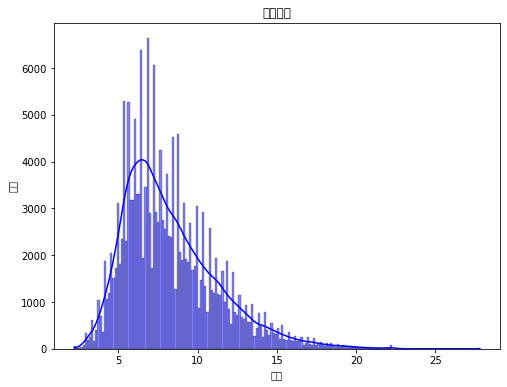

偏度值: 1.07


In [35]:
# 血糖值的分布图
plt.figure(figsize=(8, 6))
sns.histplot(train['bg+1:00'], kde=True, color='blue')
plt.title('血糖分布')
plt.xlabel('血糖')
plt.ylabel('频率')
plt.show()

# 计算偏度
skewness_value = skew(train['bg+1:00'])
print(f"偏度值: {skewness_value:.2f}")

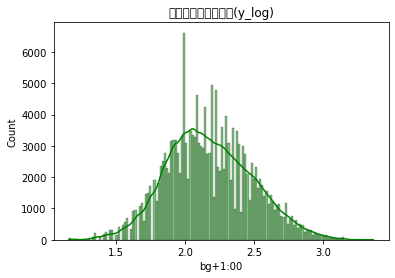

对数转换后偏度值: 0.21


In [36]:
# 血糖核密度图分布右偏， 做对数转换
train['bg+1:00'] = np.log1p(train['bg+1:00'])

sns.histplot(train['bg+1:00'], kde=True, color='green')
plt.title('血糖对数转换后分布(y_log)')
plt.show()
log_skewness_value = skew(train['bg+1:00'])
print(f"对数转换后偏度值: {log_skewness_value:.2f}")

# 训练集和测试集划分

In [37]:
# 训练集和测试集划分
target_column = 'bg+1:00'
X = train.drop(columns=[target_column])
y = train[target_column]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_new = X_train.reset_index(drop=True)
y_train_new = y_train.reset_index(drop=True)

X_test_new = X_test.reset_index(drop=True)
y_test_new = y_test.reset_index(drop=True)

# 特征编码

In [38]:
# 数值型不做标准化处理
# 特征编码
numeric_features = X_train_new.select_dtypes(include=['int64', 'int32', 'float64']).columns.tolist() # 数值型
categorical_features = X_train_new.select_dtypes(include=['object']).columns.tolist() # 字符型

# 实例化类
numeric_transformer = RobustScaler()
categorical_transformer = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1) # 将分类做整数编码

preprocessor = ColumnTransformer(
    transformers=[
        ('num',  'passthrough', numeric_features),
        ('cat', categorical_transformer, categorical_features)  # Apply OrdinalEncoder to categorical columns
    ]
)

X_train_new = preprocessor.fit_transform(X_train_new)
X_test_new = preprocessor.transform(X_test_new) 

# 模型训练

In [22]:
import xgboost as xgb
import lightgbm as lgb
from xgboost import XGBRegressor 
# from sklearn.ensemble import RandomForestRegressor
# from catboost import CatBoostRegressor
import pickle

In [23]:
# 输出写入
def write_to_notebook_simple(content, filename='output.txt', mode='a'):

    with open(filename, mode, encoding='utf-8') as f:
        if isinstance(content, str):
            f.write(content + '\n')
        else:
            f.write(str(content) + '\n')
    # 同时在控制台显示
#     print(f"[已写入] {content}")


In [39]:
# 模型训练
kf = KFold(n_splits=3, shuffle=True)
models = {
    'XGBoost': xgb.XGBRegressor(tree_method='hist',
        objective='reg:squarederror',
        n_estimators=5000,  # 从3000降到2000
        learning_rate=0.05,  # 添加适当的学习率
        max_depth=8,         # 控制树深度
        subsample=0.8,       # 采样
        colsample_bytree=0.8, # 特征采样
        reg_alpha=0.1,       # L1正则
        reg_lambda=1.0,      # L2正则
        eval_metric="rmse",
        gamma=0.1, # 分裂增益阈值
        n_jobs=-1,
        early_stopping_rounds=50,  # 添加早停
        random_state=42),
    'LightGBM': lgb.LGBMRegressor(n_estimators=5000,     # 从3000降到2000
        learning_rate=0.05,    # 添加学习率
        num_leaves=127,         # 控制复杂度
        max_depth=-1,          # 自动调整
        subsample=0.8,         # 采样
        colsample_bytree=0.8,  # 特征采样
        reg_alpha=0,         # L1正则
        reg_lambda=0,        # L2正则
        n_jobs=-1,
        verbose=-1,          # 不输出
        random_state=42)
}

In [40]:
fold = 1
os.makedirs("模型储存", exist_ok=True)
for train_index, val_index in kf.split(X_train_new):
    X_train_fold, X_val_fold = X_train_new[train_index], X_train_new[val_index]
    y_train_fold, y_val_fold = y_train_new.iloc[train_index], y_train_new.iloc[val_index]

    for name, model in models.items():
        print(f"模型： {name} on 第 {fold} 次...")
        if name == 'XGBoost':   
            model.fit(X_train_fold, y_train_fold,eval_set=[(X_val_fold, y_val_fold)],verbose=False)
        else:
            model.fit(X_train_fold, y_train_fold)

        y_pred_log = model.predict(X_val_fold)
        y_pred = np.expm1(y_pred_log)  # 因为之前为了满足正态分布进行对数转换，这里还原
        y_val_actual = np.expm1(y_val_fold)
        
        # 评估指标
        rmse = np.sqrt(mean_squared_error(y_val_actual, y_pred))
        mae = mean_absolute_error(y_val_actual, y_pred)
        r2 = r2_score(y_val_actual, y_pred)
        
        write_to_notebook_simple((f"{name} - Fold {fold} - RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}"), 'my_notes.txt')
#         print(f"{name} - Fold {fold} - RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")
        
        with open(f"模型储存/{name}_model_fold{fold}_new_1229.pkl", "wb") as f: pickle.dump(model, f)
#         with open(f"{name}_model_fold{fold}_new_1229.pkl", "wb") as file:
#             pickle.dump(model, file)
        print(f"Saved {name} model for Fold {fold}.")
    fold += 1

模型： XGBoost on 第 1 次...
Saved XGBoost model for Fold 1.
模型： LightGBM on 第 1 次...
Saved LightGBM model for Fold 1.
模型： XGBoost on 第 2 次...
Saved XGBoost model for Fold 2.
模型： LightGBM on 第 2 次...
Saved LightGBM model for Fold 2.
模型： XGBoost on 第 3 次...
Saved XGBoost model for Fold 3.
模型： LightGBM on 第 3 次...
Saved LightGBM model for Fold 3.


<Figure size 720x432 with 0 Axes>

In [43]:
# 训练集中的测试集
model_names = ['XGBoost', 'LightGBM'] 
num_folds = 3  
rmse_scores = []
mae_scores = []
r2_scores = []
all_residuals = []  

y_val_actual = np.expm1(y_test_new)

write_to_notebook_simple('测试集结果：', 'my_notes.txt')
for fold in range(1, num_folds + 1):
    for model_name in model_names:
        model_file = f'模型储存/{model_name}_model_fold{fold}_new_1229.pkl'
        with open(model_file, 'rb') as f:
            model = pickle.load(f)
        y_pred_log = model.predict(X_test_new)  
        y_pred = np.expm1(y_pred_log) 
        rmse = np.sqrt(mean_squared_error(y_val_actual, y_pred))
        mae = mean_absolute_error(y_val_actual, y_pred)
        r2 = r2_score(y_val_actual, y_pred)
        write_to_notebook_simple((f"{model_name} - Fold {fold} - RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}"), 'my_notes.txt')
#         print(f"{model_name} - Fold {fold} - RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

# 预测

In [44]:
# 对测试集进行预测
test_df = test.drop(columns=['id'])
test_df = test_df.reset_index(drop=True)

test_numeric_columns = test_df.select_dtypes(include=['int64', 'int32', 'float64']).columns.tolist()
test_categorical_columns = test_df.select_dtypes(include=['object']).columns.tolist()
test_processed = preprocessor.transform(test_df)

model_file = r'模型储存\LightGBM_model_fold1_new_1229.pkl'  # Path to the model file
with open(model_file, 'rb') as f:
    model = pickle.load(f)
y_pred_log = model.predict(test_processed)  
y_pred = np.expm1(y_pred_log) 

submission_df = pd.DataFrame({
    'id': test['id'], 
    'bg+1:00': y_pred  
})
print(submission_df.head())
submission_df.to_csv('submission.csv', index=False)

         id   bg+1:00
0  p01_8459  8.111634
1  p01_8460  5.808430
2  p01_8461  7.326539
3  p01_8462  9.438996
4  p01_8463  7.120415
